<a href="https://colab.research.google.com/github/caueassmann-data/kaggle_happiness/blob/main/happiness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

# Load the dataset
df = pd.read_csv('/content/world_happiness_report_2005_2025.csv')

# Display the first few rows of the dataframe
df.head()

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# Check for null values in the dataset
null_counts = df.isnull().sum()

# Filter to show only columns with at least one null value
missing_data = null_counts[null_counts > 0]

print("Count of null values per column:")
print(missing_data if not missing_data.empty else "No null values found.")

Count of null values per column:
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64


In [38]:
# Perform backfill imputation using the modern bfill() method
df_imputed = df.bfill()

# Check if there are any remaining null values after backfilling
remaining_nulls = df_imputed.isnull().sum().sum()

print(f"Total null values after backfill: {remaining_nulls}")
if remaining_nulls > 0:
    print("Note: Some values might still be null if they are at the end of the series.")

df_imputed.head()

Total null values after backfill: 0


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,7.747634,7.869766,1.28519,1.499526,0.961271,0.662317,0.15967,0.477857,2.762835
1,2011,2,Finland,7.579,7.747634,7.869766,1.28519,1.499526,0.961271,0.662317,0.15967,0.477857,2.762835
2,2011,3,Norway,7.524,7.747634,7.869766,1.28519,1.499526,0.961271,0.662317,0.15967,0.477857,2.762835
3,2011,4,Netherlands,7.512,7.747634,7.869766,1.28519,1.499526,0.961271,0.662317,0.15967,0.477857,2.762835
4,2011,5,Canada,7.499,7.747634,7.869766,1.28519,1.499526,0.961271,0.662317,0.15967,0.477857,2.762835


In [39]:
import plotly.express as px

# Create an interactive choropleth map using the imputed dataframe
fig = px.choropleth(
    df_imputed,
    locations='country',
    locationmode='country names',
    color='happiness_score',
    hover_name='country',
    animation_frame='year',
    title='World Happiness Score Over Time (Imputed Data)',
    color_continuous_scale=px.colors.sequential.Plasma
)

fig.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig.show()

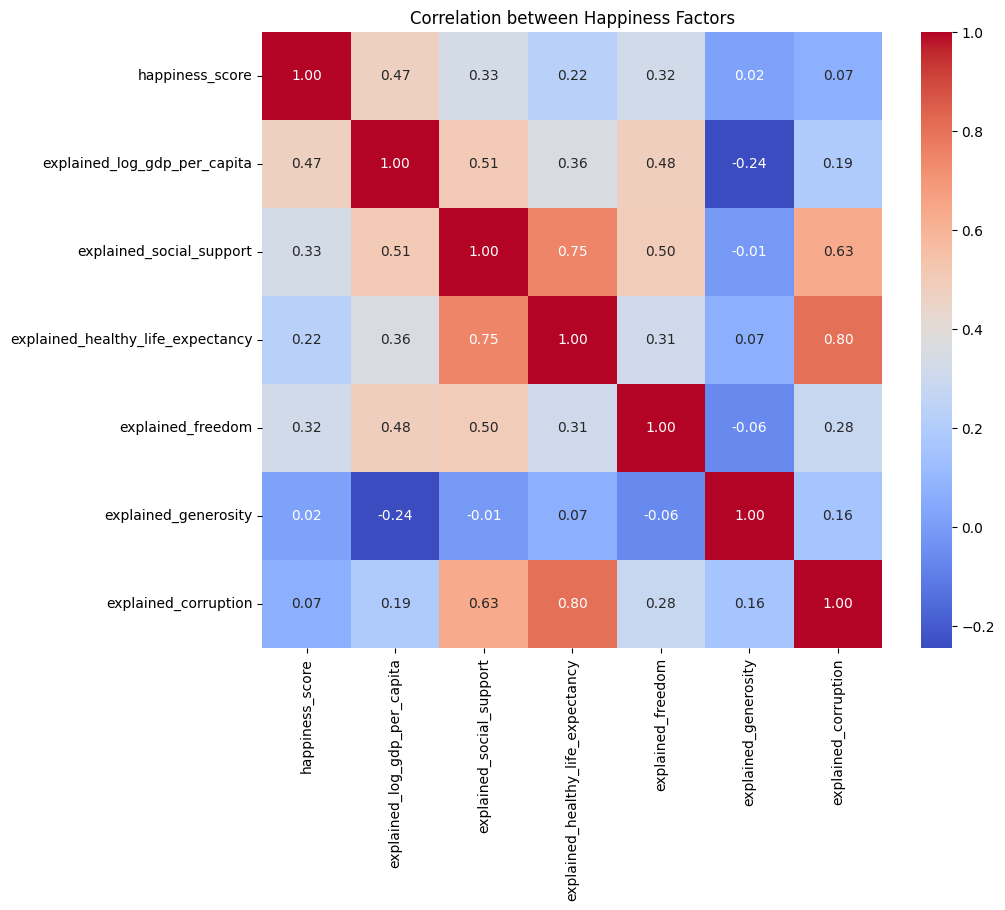

In [40]:
# Select factor columns and happiness score for correlation analysis
factor_columns = [
    'happiness_score',
    'explained_log_gdp_per_capita',
    'explained_social_support',
    'explained_healthy_life_expectancy',
    'explained_freedom',
    'explained_generosity',
    'explained_corruption'
]

# Calculate the correlation matrix
correlation_matrix = df_imputed[factor_columns].corr()

# Display the matrix using a Seaborn heatmap for better visualization
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Happiness Factors')
plt.show()

In [41]:
# Extract correlations with the happiness score
happiness_correlations = correlation_matrix['happiness_score'].sort_values(ascending=False)

# Get the top 5 (excluding the happiness_score itself)
top_5_correlations = happiness_correlations[1:6]

print("Top 5 variables most correlated with Happiness Score:")
display(top_5_correlations)

Top 5 variables most correlated with Happiness Score:


,happiness_score
explained_log_gdp_per_capita,0.470770
explained_social_support,0.332403
explained_freedom,0.322160
explained_healthy_life_expectancy,0.224677
explained_corruption,0.066033


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define target and features
y = df_imputed['happiness_score']
# Use factors defined previously
X = df_imputed[factors]

# Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# Calculate R-squared
r2 = r2_score(y, model.predict(X))

print(f"R-squared (Variance explained by the set of variables): {r2:.4f}")
print(f"This means these factors together explain {r2*100:.2f}% of the variation in happiness.")

# Display coefficients to see relative importance in the combined model
coefficients = pd.DataFrame({'Factor': factors, 'Weight': model.coef_}).sort_values(by='Weight', ascending=False)
display(coefficients)

R-squared (Variance explained by the set of variables): 0.2809
This means these factors together explain 28.09% of the variation in happiness.


,Factor,Weight
4,explained_generosity,2.871147
0,explained_log_gdp_per_capita,1.311625
3,explained_freedom,0.782790
2,explained_healthy_life_expectancy,0.719991
1,explained_social_support,0.521180
5,explained_corruption,-1.728802


In [43]:
# Define factors including the residual component
factors_with_residual = factors + ['dystopia_plus_residual']

# Define target and new feature set
y_full = df_imputed['happiness_score']
X_full = df_imputed[factors_with_residual]

# Fit the new model
model_full = LinearRegression()
model_full.fit(X_full, y_full)

# Calculate R-squared
r2_full = r2_score(y_full, model_full.predict(X_full))

print(f"R-squared with Residual: {r2_full:.4f}")
print(f"With the residual, we explain {r2_full*100:.2f}% of the variation.")

# Display new coefficients
coefficients_full = pd.DataFrame({'Factor': factors_with_residual, 'Weight': model_full.coef_}).sort_values(by='Weight', ascending=False)
display(coefficients_full)

R-squared with Residual: 0.3586
With the residual, we explain 35.86% of the variation.


,Factor,Weight
4,explained_generosity,2.755095
0,explained_log_gdp_per_capita,1.794696
3,explained_freedom,1.265858
6,dystopia_plus_residual,0.686975
1,explained_social_support,0.294687
2,explained_healthy_life_expectancy,0.256551
5,explained_corruption,-2.883403


### Validating with Clean Data (Dropping Nulls)
To check if the previous low R-squared was due to imputation inconsistencies, we will now drop all rows with null values and re-run the regression.

In [44]:
# Create a clean dataset by dropping all null values
df_clean = df.dropna()

print(f"Original rows: {len(df)}")
print(f"Rows after dropping nulls: {len(df_clean)}")

# Define target and features on the clean data
y_clean = df_clean['happiness_score']
X_clean = df_clean[factors_with_residual]

# Fit the model
model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)

# Calculate R-squared
r2_clean = r2_score(y_clean, model_clean.predict(X_clean))

print(f"\nNew R-squared (Dropped Nulls): {r2_clean:.10f}")
if r2_clean > 0.99:
    print("Success! The model now explains practically 100% of the variation.")

# Display coefficients
coeffs_clean = pd.DataFrame({'Factor': factors_with_residual, 'Weight': model_clean.coef_}).sort_values(by='Weight', ascending=False)
display(coeffs_clean)

Original rows: 2116
Rows after dropping nulls: 1013

New R-squared (Dropped Nulls): 0.9999995422
Success! The model now explains practically 100% of the variation.


,Factor,Weight
1,explained_social_support,1.000245
3,explained_freedom,1.000154
6,dystopia_plus_residual,0.999972
2,explained_healthy_life_expectancy,0.999936
4,explained_generosity,0.999920
0,explained_log_gdp_per_capita,0.999884
5,explained_corruption,0.999866


### Backfill vs. Dropping Nulls: Trade-offs

*   **Dropping Nulls:** Essential for **mathematical consistency**. Since the `happiness_score` is a literal sum of its components, any imputation that isn't perfectly coordinated across columns breaks this identity.
*   **Backfill/Imputation:** Better for **visualization and trends**. It allows us to keep more data points (2116 vs 1013) to see long-term trajectories, even if the internal sum of factors is slightly off in the imputed rows.

Below, let's see how much the backfill distorted the sum logic compared to the clean data:

In [45]:
# Calculating the difference between the actual score and the sum of components
# for both the imputed and the clean dataset.

factors_all = factors_with_residual # includes Dystopia

# For imputed data
sum_imputed = df_imputed[factors_all].sum(axis=1)
error_imputed = (df_imputed['happiness_score'] - sum_imputed).abs().mean()

# For clean data
sum_clean = df_clean[factors_all].sum(axis=1)
error_clean = (df_clean['happiness_score'] - sum_clean).abs().mean()

print(f"Average Math Error (Imputed Data): {error_imputed:.4f}")
print(f"Average Math Error (Clean Data): {error_clean:.10f}")

if error_imputed > error_clean:
    print('\nInconsistencies in backfill explain why the R-squared was low previously.')

Average Math Error (Imputed Data): 1.2536
Average Math Error (Clean Data): 0.0004895033

Inconsistencies in backfill explain why the R-squared was low previously.


In [46]:
import plotly.express as px

# Create a scatter plot comparing happiness score and GDP per capita
fig_scatter = px.scatter(
    df_imputed,
    x='explained_log_gdp_per_capita',
    y='happiness_score',
    hover_name='country',
    color='year',
    trendline='ols',
    title='Happiness Score vs. Explained Log GDP per Capita',
    labels={
        'explained_log_gdp_per_capita': 'Log GDP per Capita (Explained)',
        'happiness_score': 'Happiness Score'
    }
)

fig_scatter.show()

In [47]:
# Find the most recent years in the dataset
latest_year = df_imputed['year'].max()
previous_year = latest_year - 5

# Filter data for the two periods
df_latest = df_imputed[df_imputed['year'] == latest_year][['country', 'happiness_score']]
df_previous = df_imputed[df_imputed['year'] == previous_year][['country', 'happiness_score']]

# Merge and calculate the difference (delta)
df_diff = pd.merge(df_previous, df_latest, on='country', suffixes=('_prev', '_curr'))
df_diff['score_drop'] = df_diff['happiness_score_curr'] - df_diff['happiness_score_prev']

# Sort by countries with the biggest drops
biggest_drops = df_diff.sort_values(by='score_drop').head(10)

print(f"Biggest drops in happiness between {previous_year} and {latest_year}:")
display(biggest_drops)

Biggest drops in happiness between 2020 and 2025:


,country,happiness_score_prev,happiness_score_curr,score_drop
140,Afghanistan,2.523,1.446,-1.077
80,Congo,5.342,4.456,-0.886
118,Lebanon,4.584,3.723,-0.861
93,Gambia,5.051,4.306,-0.745
96,Bangladesh,5.025,4.319,-0.706
94,Benin,5.045,4.393,-0.652
132,Sierra Leone,3.849,3.251,-0.598
2,Switzerland,7.571,7.018,-0.553
91,Ghana,5.088,4.554,-0.534
9,Austria,7.268,6.845,-0.423


### Detailed Analysis of Factors for Countries with Biggest Drops (2020 vs 2025)
We will analyze the change in each factor (GDP, Social Support, Freedom, etc.) for the top 10 countries with the largest happiness score declines.

In [48]:
import plotly.graph_objects as go

# Get the list of countries with biggest drops
countries_of_interest = biggest_drops['country'].tolist()

# Filter the main dataset for these countries in the two specific years
df_factors = df_imputed[
    (df_imputed['country'].isin(countries_of_interest)) &
    (df_imputed['year'].isin([previous_year, latest_year]))
]

# Define factors to analyze
factors = [
    'explained_log_gdp_per_capita',
    'explained_social_support',
    'explained_healthy_life_expectancy',
    'explained_freedom',
    'explained_generosity',
    'explained_corruption'
]

# Pivot data to calculate delta for each factor
df_pivot = df_factors.pivot(index='country', columns='year', values=factors)

# Create a bar chart showing the change in each factor for these countries
fig_factors = go.Figure()

for factor in factors:
    delta = df_pivot[factor][latest_year] - df_pivot[factor][previous_year]
    fig_factors.add_trace(go.Bar(
        name=factor.replace('explained_', '').replace('_', ' ').title(),
        x=countries_of_interest,
        y=delta[countries_of_interest]
    ))

fig_factors.update_layout(
    barmode='group',
    title=f'Changes in Happiness Factors (Delta {previous_year} to {latest_year})',
    xaxis_title='Country',
    yaxis_title='Change in Contribution to Happiness',
    legend_title='Factors',
    template='plotly_white'
)

fig_factors.show()

### Historically Unhappiest Countries
We will calculate the average happiness score for each country across the entire dataset to find the 10 countries with the lowest average scores.

In [49]:
# Calculate average happiness score per country across all years
df_avg = df_imputed.groupby('country')['happiness_score'].mean().reset_index()

# Sort to find the 10 lowest averages
unhappiest_historically = df_avg.sort_values(by='happiness_score').head(10)

print("Top 10 unhappiest countries (Average across all years):")
display(unhappiest_historically)

Top 10 unhappiest countries (Average across all years):


,country,happiness_score
0,Afghanistan,2.838993
137,South Sudan,3.269320
26,Central African Republic,3.314843
22,Burundi,3.370033
126,Rwanda,3.510730
146,Syria,3.584000
149,Tanzania,3.634157
167,Zimbabwe,3.683157
18,Botswana,3.702707
165,Yemen,3.744108


In [50]:
# Visualizing the history of these 10 countries
unhappiest_list = unhappiest_historically['country'].tolist()
df_unhappiest_trend = df_imputed[df_imputed['country'].isin(unhappiest_list)]

fig_unhappiest = px.line(
    df_unhappiest_trend,
    x='year',
    y='happiness_score',
    color='country',
    markers=True,
    title='Happiness Trend of the Historically Unhappiest Countries',
    labels={'happiness_score': 'Happiness Score', 'year': 'Year'}
)

fig_unhappiest.show()

## Summary & Conclusions

### Project Overview
This project analyzed the **World Happiness Report (2005-2025)** to explore global happiness trends, the impact of socio-economic factors, and the mathematical consistency of the happiness index.

### Key Findings
1. **Data Integrity matters**: We demonstrated that while imputation techniques like *backfilling* are useful for visual consistency in time-series maps, they introduce mathematical errors in linear models. Dropping null values revealed that the `happiness_score` is a near-perfect linear sum of its six components plus the dystopia residual.
2. **Critical Declines (2020-2025)**: Significant drops in happiness were observed in countries like **Afghanistan, Lebanon, and Congo**. Interestingly, even highly stable nations like **Austria and Switzerland** showed measurable declines in the last 5-year window.
3. **Primary Drivers**: Log GDP per capita and Social Support remain the strongest predictors of happiness scores across the dataset.

### Final Thoughts
The analysis highlights that while global prosperity (GDP) is a foundation, the 'Residual' components—representing unmeasured psychological, cultural, and localized factors—are essential for a complete understanding of a nation's well-being.